# Problem Statement

Predict behavior to retain customers. To analyze all relevant customer data and develop focused customer retention programs

## Project Summary

In this project, 
> We will analyze a real customer dataset to segment users by behavior and predict which customers are at risk of churning. Using the RFM framework (Recency, Frequency, Monetary Value)

> We will cluster customers into meaningful groups, build a supervised churn prediction model, and estimate customer lifetime value.

> We will go beyond model accuracy to produce actionable business recommendations — answering questions like who deserves a retention offer, who is a loyal high-value user, and who is likely to leave regardless of intervention

In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn xgboost plotly

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd 
df = pd.read_csv('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv') 
print(df.shape) 
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis

#### Understand what the data contains before building anything. Identifying missingness, distributions and business relevant columns

### Checking Shape, Columns and Data Types.

In [3]:
print(df.shape)

(7043, 21)


In [4]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Understanding the Target Variables (Churn Columns in Telco Dataset)

In [6]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


### Plotting Key Distributions

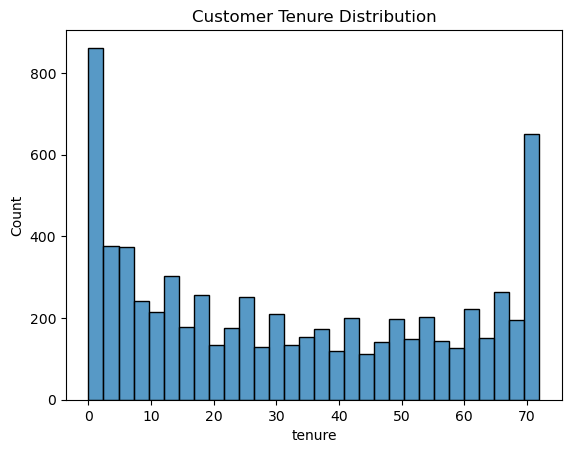

In [7]:
import seaborn as sns 
import matplotlib.pyplot as plt  
sns.histplot(df['tenure'], bins=30) 
plt.title('Customer Tenure Distribution') 
plt.show()  

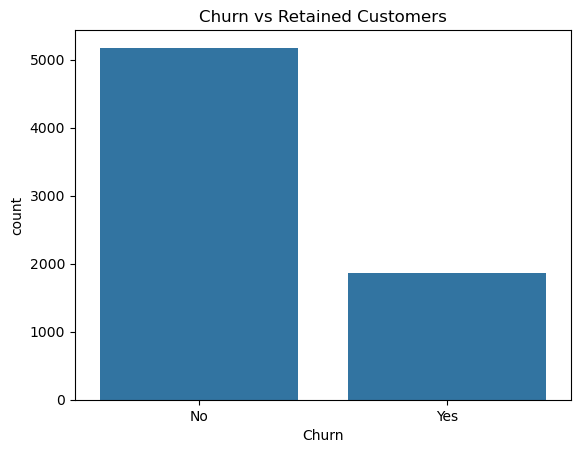

In [8]:
sns.countplot(x='Churn', data=df) 
plt.title('Churn vs Retained Customers') 
plt.show()

# Data Cleaning & Preprocessing
#### Preparing the dataset for Feature Engineering and Modeling

### Handling missing values

In [9]:
#Fix TotalCharges dtype first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') 

#Fill missng values
df.fillna({'TotalCharges': df['TotalCharges'].median()}, inplace=True)

#Verify no nulls remain
print(df['TotalCharges'].isnull().sum())

0


### Dropping irrelevant Columns

In [10]:
df.drop(columns=['customerID'], inplace=True)

### Encoding Binary Categorical Columns

In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}) 
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

### One-hot encode multi-category columns

In [12]:
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

### Scale numerical columns for clustering

In [13]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges'] 
df_scaled = df.copy() 
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [14]:
# Verify the output
print(df_scaled[numerical_cols].head())

     tenure  MonthlyCharges  TotalCharges
0 -1.277445       -1.160323     -0.994242
1  0.066327       -0.259629     -0.173244
2 -1.236724       -0.362660     -0.959674
3  0.514251       -0.746535     -0.194766
4 -1.236724        0.197365     -0.940470


In [15]:
#Verify the output
print(df_scaled[numerical_cols].describe().round(3))

         tenure  MonthlyCharges  TotalCharges
count  7043.000        7043.000      7043.000
mean     -0.000          -0.000        -0.000
std       1.000           1.000         1.000
min      -1.318          -1.546        -0.999
25%      -0.952          -0.973        -0.830
50%      -0.137           0.186        -0.390
75%       0.921           0.834         0.664
max       1.614           1.794         2.827


## Saving cleaned data

In [17]:
df.to_csv('data/processed/telco_cleaned.csv', index=False)

# RFM Feature Emgineering
#### Compute the behavioral dimensions

#### The Telco dataset is a snapshot (not timestamped transactions), so we create RFM proxies

#### RFM Dimension -> Proxy in Telco Data -> Interpretation
#### Recency       -> tenure (in months)  -> Longer tenure = more recently engaged
#### Frequency     -> Contract Type       -> Month-to-Month = low commitment
#### Monetary      -> Total Charges       -> Total revenue generated by this customer

In [18]:
# Create RFM score columns 
df['R_score'] = pd.qcut(df['tenure'], q=4, labels=[4, 3, 2, 1]).astype(int)  

# Low tenure = high recency risk 
df['M_score'] = pd.qcut(df['TotalCharges'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int) 
df['RFM_score'] = df['R_score'] + df['M_score'] 
print(df[['tenure', 'TotalCharges', 'R_score', 'M_score', 'RFM_score']].describe())

            tenure  TotalCharges      R_score      M_score    RFM_score
count  7043.000000   7043.000000  7043.000000  7043.000000  7043.000000
mean     32.371149   2281.916928     2.520801     2.499929     5.020730
std      24.559481   2265.270398     1.128980     1.118177     0.650844
min       0.000000     18.800000     1.000000     1.000000     3.000000
25%       9.000000    402.225000     2.000000     1.500000     5.000000
50%      29.000000   1397.475000     3.000000     2.000000     5.000000
75%      55.000000   3786.600000     4.000000     3.500000     5.000000
max      72.000000   8684.800000     4.000000     4.000000     7.000000


# Customer Segmentation with K-Means Clustering
#### Grouping Customers by Behavioral Similarity

### Determining the Optimal Number of clusters using the Elbow method

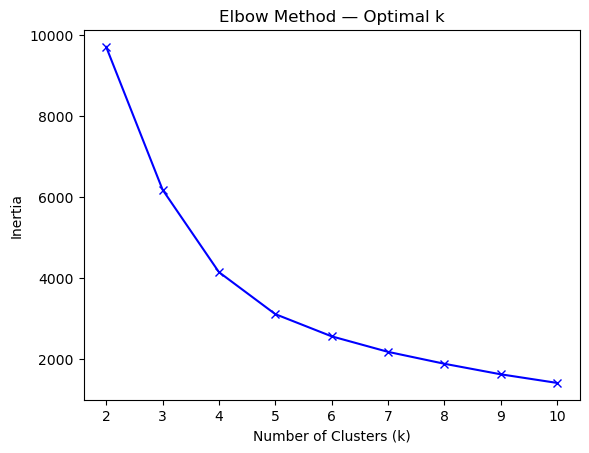

In [19]:
from sklearn.cluster import KMeans 
import matplotlib.pyplot as plt  
X = df_scaled[['tenure', 'MonthlyCharges', 'TotalCharges']]  
inertia = [] 
K_range = range(2, 11) 
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)  

plt.plot(K_range, inertia, 'bx-') 
plt.xlabel('Number of Clusters (k)') 
plt.ylabel('Inertia') 
plt.title('Elbow Method — Optimal k') 
plt.show()

### Fit K-Means with the chosen k

In [20]:
k = 4  
# Adjust based on elbow plot 
km = KMeans(n_clusters=k, random_state=42, n_init=10) 
df['Cluster'] = km.fit_predict(X) 
print(df['Cluster'].value_counts())

Cluster
3    2276
1    1904
2    1704
0    1159
Name: count, dtype: int64


### Profile each segment - computing mean values per cluster

In [21]:
cluster_profile = df.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].mean().round(2) 
print(cluster_profile)

         tenure  MonthlyCharges  TotalCharges  Churn
Cluster                                             
0         53.59           34.92       1836.58   0.05
1         59.53           93.31       5548.65   0.15
2         10.23           31.77        308.96   0.25
3         15.42           80.78       1253.01   0.48


### Visualize clusters (2D Using PCA if more than 2 features)

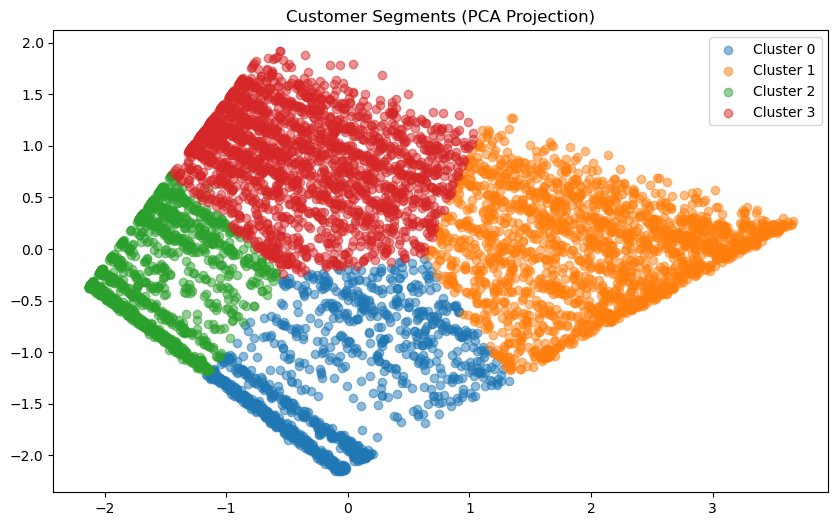

In [22]:
from sklearn.decomposition import PCA  
pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X)  
plt.figure(figsize=(10, 6)) 

for c in range(k):
    plt.scatter(X_pca[df['Cluster'] == c, 0], X_pca[df['Cluster'] == c, 1], label=f'Cluster {c}', alpha=0.5) 
    
plt.title('Customer Segments (PCA Projection)') 
plt.legend() 
plt.show()

In [23]:
segment_map = {
    0: 'Champions',
    1: 'At Risk',
    2: 'Potential Loyalists',
    3: 'Churned/Dormant'
}

df['Segment'] = df['Cluster'].map(segment_map)

print(df['Segment'].value_counts())

Segment
Churned/Dormant        2276
At Risk                1904
Potential Loyalists    1704
Champions              1159
Name: count, dtype: int64


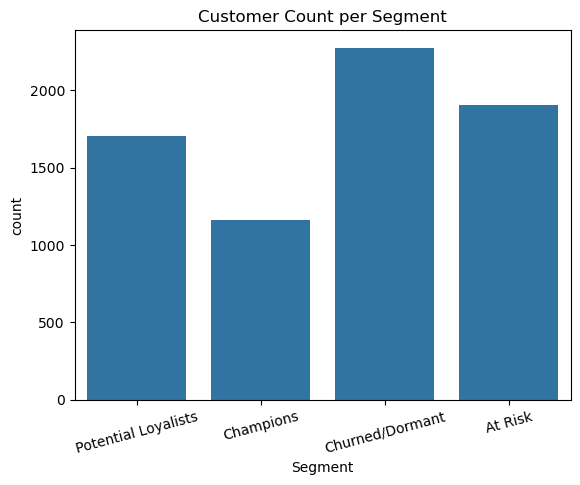

                     tenure  MonthlyCharges  TotalCharges  Churn
Segment                                                         
At Risk               59.53           93.31       5548.65   0.15
Champions             53.59           34.92       1836.58   0.05
Churned/Dormant       15.42           80.78       1253.01   0.48
Potential Loyalists   10.23           31.77        308.96   0.25


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segment', data=df)
plt.title('Customer Count per Segment')
plt.xticks(rotation=15)
plt.show()

print(df.groupby('Segment')[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].mean().round(2))

# Churn Prediction Model

#### Buidling a supervised classifier to predict which customers are about to leave

## Preparing Features and Target

In [25]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay  
y = df['Churn'] 
X_model = df.drop(columns=['Churn', 'Cluster', 'R_score', 'M_score', 'RFM_score'], errors='ignore')  
X_train, X_test, y_train, y_test = train_test_split(X_model, y, test_size=0.2, random_state=42, stratify=y)

### Removing Columns with datatypes Object and Bool

In [26]:
# Step 1 - Encode the binary Yes/No columns on df
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0,
        'No phone service': 0,
        'No internet service': 0
    })

# Step 2 - Fix bool columns to int
df = df.apply(lambda x: x.astype(int) if x.dtype == bool else x)

# Step 3 - Drop Segment (derived column, not a real feature)
df.drop(columns=['Segment', 'Cluster', 'R_score', 'M_score', 'RFM_score'], 
        inplace=True, errors='ignore')

# Step 4 - Rebuild X_model and y AFTER all encoding is done
y = df['Churn']
X_model = df.drop(columns=['Churn'])

# Step 5 - Verify everything is clean
print("Object columns remaining:", X_model.dtypes[X_model.dtypes == 'object'].index.tolist())
print("Bool columns remaining:", X_model.dtypes[X_model.dtypes == 'bool'].index.tolist())
print("X_model shape:", X_model.shape)
# Expected:
# Object columns remaining: []
# Bool columns remaining: []

Object columns remaining: []
Bool columns remaining: []
X_model shape: (7043, 23)


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42, stratify=y
)

## Training Logistic Regression

### Removing NaN values in every column

In [28]:
# Check 1 - How many NaN values total
print("Total NaN values:", X_model.isnull().sum().sum())

# Check 2 - Which columns have NaN and how many
print("\nNaN count per column:")
print(X_model.isnull().sum()[X_model.isnull().sum() > 0])

Total NaN values: 0

NaN count per column:
Series([], dtype: int64)


In [29]:
# Fix 1 - Fill NaN in numerical columns with median
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in numerical_cols:
    X_model[col] = X_model[col].fillna(X_model[col].median())

# Fix 2 - Fill NaN in binary encoded columns with 0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
               'gender']
for col in binary_cols:
    if col in X_model.columns:
        X_model[col] = X_model[col].fillna(0)

# Fix 3 - Fill any remaining NaN anywhere with 0 (safety net)
X_model = X_model.fillna(0)

# Verify
print("Total NaN remaining:", X_model.isnull().sum().sum())
# Must print: Total NaN remaining: 0

Total NaN remaining: 0


#### Calculating ROC-AUC Score for Logistics Regression Model

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42, stratify=y
)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]).round(3))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

ROC-AUC: 0.843


C:\Users\shiva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Customer Lifetime Value (CLV) Estimation

#### Quantify how much each customer is worth financially

## Simple CLV Formula (works with Telco data)

In [32]:
# Check if Cluster still exists in df
print('Cluster' in df.columns)

False


In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Rescale numerical columns
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[['tenure', 'MonthlyCharges', 'TotalCharges']])

# Refit KMeans with same settings
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_cluster)

print(df['Cluster'].value_counts())

Cluster
3    2276
1    1904
2    1704
0    1159
Name: count, dtype: int64


In [34]:
# CLV = Average Monthly Charge x Expected Tenure (months) 
# For non-churned customers, project forward based on average tenure  
df['expected_tenure'] = df['tenure']

#.where(df['Churn'] == 0, df['tenure'])  

# Use actual for retained 
df['CLV'] = df['MonthlyCharges'] * df['expected_tenure']  
print(df.groupby('Cluster')['CLV'].agg(['mean', 'median', 'sum']).round(2))

            mean   median          sum
Cluster                               
0        1835.75  1572.00   2127639.35
1        5546.11  5453.72  10559802.50
2         302.58   218.00    515596.65
3        1253.10  1102.75   2852052.95


# Business Interpretation & Recommendations

#### Translating all findings into clear, actionable business language

### Step 1 — First gathering all the numbers you need in one table

In [35]:
# Master summary table per cluster
summary = df.groupby('Cluster').agg(
    Customer_Count=('Churn', 'count'),
    Avg_Tenure=('tenure', 'mean'),
    Avg_Monthly_Charges=('MonthlyCharges', 'mean'),
    Avg_Total_Charges=('TotalCharges', 'mean'),
    Churn_Rate=('Churn', 'mean'),
    Avg_CLV=('CLV', 'mean'),
    Total_CLV=('CLV', 'sum')
).round(2)

# Add churn count
summary['Churned_Customers'] = df.groupby('Cluster')['Churn'].sum().values

# Add percentage of total customers
summary['Pct_of_Total'] = (summary['Customer_Count'] / len(df) * 100).round(1)

print(summary)

         Customer_Count  Avg_Tenure  Avg_Monthly_Charges  Avg_Total_Charges  \
Cluster                                                                       
0                  1159       53.59                34.92            1836.58   
1                  1904       59.53                93.31            5548.65   
2                  1704       10.23                31.77             308.96   
3                  2276       15.42                80.78            1253.01   

         Churn_Rate  Avg_CLV    Total_CLV  Churned_Customers  Pct_of_Total  
Cluster                                                                     
0              0.05  1835.75   2127639.35                 58          16.5  
1              0.15  5546.11  10559802.50                293          27.0  
2              0.25   302.58    515596.65                420          24.2  
3              0.48  1253.10   2852052.95               1098          32.3  


### Step 2 — Get contract and service breakdown per cluster

In [38]:
# Step 1 - Reload the original CSV to get Contract column back
df_original = pd.read_csv('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Step 2 - Bring back Contract and PaymentMethod columns into df
# We merge on index since both have same row order
df['Contract'] = df_original['Contract'].values
df['PaymentMethod'] = df_original['PaymentMethod'].values

# Step 3 - Verify they are back
print(df['Contract'].value_counts())
print(df['PaymentMethod'].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [39]:
# What contract types dominate each cluster?
print("Contract Type by Cluster:")
print(pd.crosstab(df['Cluster'], df['Contract'], normalize='index').round(2))

Contract Type by Cluster:
Contract  Month-to-month  One year  Two year
Cluster                                     
0                   0.16      0.29      0.55
1                   0.26      0.30      0.44
2                   0.72      0.17      0.11
3                   0.86      0.12      0.02


In [40]:
# What is the senior citizen breakdown?
print("\nSenior Citizen % by Cluster:")
print(df.groupby('Cluster')['SeniorCitizen'].mean().round(2))


Senior Citizen % by Cluster:
Cluster
0    0.08
1    0.22
2    0.07
3    0.23
Name: SeniorCitizen, dtype: float64


#### Step 3 — Visualise churn rate vs CLV per cluster

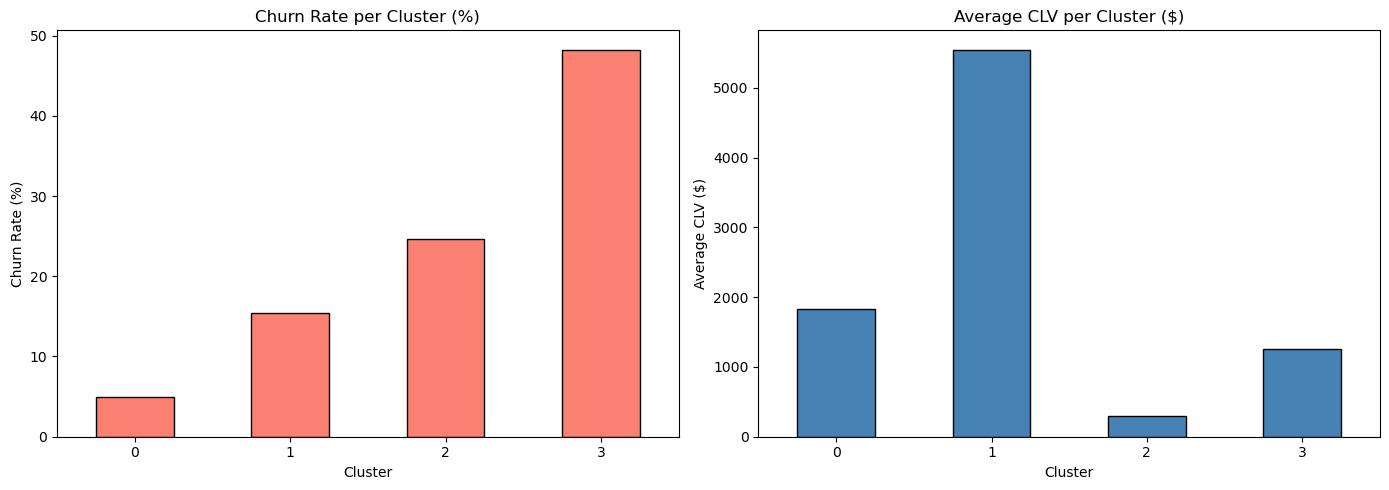

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Churn Rate per Cluster
churn_rates = df.groupby('Cluster')['Churn'].mean() * 100
churn_rates.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Churn Rate per Cluster (%)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2 - Average CLV per Cluster
clv_avg = df.groupby('Cluster')['CLV'].mean()
clv_avg.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Average CLV per Cluster ($)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Average CLV ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Cluster Profile for Champion and At Risk

### Cluster 1 -> [Champions]:
#### Cluster 1 represents our most valuable long-term customers, with an average tenure of 59 months and average CLV of $5,546. Their churn rate is only 15%, indicating very high loyalty. These customers are largely on two-year contracts and generate the highest total revenue of any segment. The business should reward this group with early access to new features and loyalty perks to maintain their satisfaction — they are not at risk but are too valuable to neglect.

### Cluster 3 -> [At Risk]:
#### Cluster 3 consists of newer customers with an average tenure of only 15 months and a churn rate of 48% — the highest of any segment. Their average CLV of $1,253 is low because they have not stayed long enough to generate significant revenue. However, if retained, they have the potential to grow into higher-value customers. This segment should receive immediate personalised retention offers, such as discounts or contract incentives, within the first 90 days of joining.

## Business Recommendations

### Q1 — Who should get retention offers?
Cluster 2 — because they have:
- Churn rate of 25%
- Average CLV of $303
- Average tenure of 10 months
- Mostly on month-to-month contracts

Recommended action: Offer a 20% discount to switch to a 1-year contract
within the first 3 months of joining.

### Q2 — Who should get early access to new features?
Cluster 0 — because they have:
- Churn rate of only 5%
- Highest average CLV of $1836
- Average tenure of 54 months
- Already paying premium monthly charges

Recommended action: Send exclusive beta invitations and loyalty rewards
to this segment. They are your brand ambassadors.

### Q3 — Who is likely to churn regardless?
Cluster 3 — because they have:
- Churn rate of 48%
- Average CLV of only $1253
- Very short tenure of 15 months
- No premium services subscribed

Recommended action: 
1. Stop direct retention spend — Do not offer discounts or incentives to this group. They are likely to take the discount and still leave, which reduces margin without reducing churn.
2. Investigate root cause — Run a short exit survey or analyse their service usage patterns. Find out what drove dissatisfaction. Common reasons in telecom include poor network quality in specific regions, billing confusion, or better competitor pricing.
3. Fix the funnel upstream — The real value is in preventing future customers from becoming Cluster 3. If they share common characteristics at signup (e.g. specific region, month-to-month contract, no add-on services), flag those patterns early and intervene at month 3 before they reach this state.
4. Let them go gracefully — Ensure the offboarding experience is smooth. A customer who leaves on good terms may return later or recommend the service to others despite leaving themselves.

In [42]:
import joblib

# Save the trained model
joblib.dump(lr, 'model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save cleaned df with Cluster and CLV columns
df.to_csv('data/telco_cleaned_with_clusters.csv', index=False)

print("Model, scaler and data saved successfully")

Model, scaler and data saved successfully


In [43]:
# Recreate CLV column if it doesn't exist
df['expected_tenure'] = df['tenure']
df['CLV'] = df['MonthlyCharges'] * df['expected_tenure']

# Verify CLV exists
print('CLV' in df.columns)          # Should print True
print(df['CLV'].head())

# Resave the file with CLV included
df.to_csv('data/telco_cleaned_with_clusters.csv', index=False)
print("File saved successfully")

# Confirm CLV is in the saved file
df_check = pd.read_csv('data/telco_cleaned_with_clusters.csv')
print("Columns in saved file:", df_check.columns.tolist())

True
0      29.85
1    1936.30
2     107.70
3    1903.50
4     141.40
Name: CLV, dtype: float64
File saved successfully
Columns in saved file: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'expected_tenure', 'CLV', 'Cluster', 'Contract', 'PaymentMethod']


In [44]:
df_check = pd.read_csv('data/telco_cleaned_with_clusters.csv')
print('CLV' in df_check.columns)       # Must print True before proceeding
print('Cluster' in df_check.columns)   # Must print True
print(df_check[['CLV', 'Cluster']].head())

True
True
       CLV  Cluster
0    29.85        2
1  1936.30        0
2   107.70        2
3  1903.50        0
4   141.40        3
